# 🐂 Rayvora Vision Pro — Fine-Tuning v3
**UFSC Araranguá | Projeto Integrador | Startup Rayvora**

### O que este notebook faz:
1. Conecta ao Google Drive e carrega as 72 imagens + measurements.xlsx
2. Aplica CLAHE (Equalização de Histograma Adaptativa) em todas as imagens
3. Usa Data Augmentation agressivo (Albumentations) para expandir de 71 → ~350 amostras
4. Treina MobileNetV2 com Transfer Learning (ImageNet) — **muito melhor que CNN do zero**
5. Faz Unfreeze das últimas camadas (Fine-Tuning real) com learning rate baixo
6. Exporta modelo final em `.h5` e `.tflite` (float32) prontos para o app

### Por que vai ser melhor que o modelo atual (MAE 32.87 kg treino / 72.44 kg teste)?
- **Transfer Learning**: MobileNetV2 já sabe extrair bordas, texturas e formas de imagens
- **CLAHE**: normaliza iluminação diferente entre fotos (principal causa do erro no teste)
- **Augmentation**: simula variações de câmera, iluminação e ângulo → menos overfitting
- **Fine-Tuning em 2 fases**: congela base → treina cabeça → descongela top → refina tudo


In [16]:
# ============================================================
# CÉLULA 1 — INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# Execute uma vez. Depois pode comentar esta célula.
!pip install albumentations==1.4.3 opencv-python-headless -q
print('✅ Dependências instaladas!')

✅ Dependências instaladas!


In [17]:
# ============================================================
# CÉLULA 2 — MONTAR DRIVE E DEFINIR CAMINHOS
# ============================================================
from google.colab import drive
import os

drive.mount('/content/drive')

# ⚠️  AJUSTE AQUI se a tua pasta no Drive tiver nome diferente
PATH_BASE  = '/content/drive/MyDrive/Projeto_Bois_IA'
PATH_IMGS  = os.path.join(PATH_BASE, 'back view')          # pasta com 1.png … 72.png
PATH_EXCEL = os.path.join(PATH_BASE, 'measurements.xlsx')  # ficheiro com Body weight (kg)
PATH_OUT   = '/content/drive/MyDrive/Projeto_Bois_IA/modelos_v3'  # onde salvar o modelo

os.makedirs(PATH_OUT, exist_ok=True)

ok_imgs  = os.path.exists(PATH_IMGS)
ok_excel = os.path.exists(PATH_EXCEL)
print(f'Pasta de imagens : {"✅" if ok_imgs  else "❌"} {PATH_IMGS}')
print(f'Ficheiro Excel   : {"✅" if ok_excel else "❌"} {PATH_EXCEL}')

if not ok_imgs or not ok_excel:
    raise FileNotFoundError('⛔ Verifica os caminhos acima antes de continuar.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta de imagens : ✅ /content/drive/MyDrive/Projeto_Bois_IA/back view
Ficheiro Excel   : ✅ /content/drive/MyDrive/Projeto_Bois_IA/measurements.xlsx


In [18]:
# ============================================================
# CÉLULA 3 — CARREGAR IMAGENS COM CLAHE
# ============================================================
# CLAHE = Contrast Limited Adaptive Histogram Equalization
# Normaliza a iluminação dentro de regiões locais da imagem.
# Isso reduz o efeito de variação de luz entre fotos (principal
# causa do MAE alto no teste cego: 72.44 kg).

import cv2
import numpy as np
import pandas as pd

IMG_SIZE = 128  # Mantém compatibilidade com o app atual

def aplicar_clahe(img_rgb):
    """Aplica CLAHE no canal L do espaço LAB e retorna RGB."""
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def carregar_dados(path_imgs, path_excel, img_size=128):
    df = pd.read_excel(path_excel)
    imagens, pesos = [], []
    nao_encontradas = []

    print(f'🔄 Carregando imagens de: {path_imgs}')
    for i in range(1, 73):
        # Tenta .png e .jpg
        for ext in ['.png', '.jpg', '.jpeg']:
            img_path = os.path.join(path_imgs, f'{i}{ext}')
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                img = aplicar_clahe(img)         # ← CLAHE aplicado aqui
                img = img.astype(np.float32) / 255.0
                imagens.append(img)
                pesos.append(float(df.iloc[i-1]['Body weight (kg)']))
                break
        else:
            nao_encontradas.append(i)

    if nao_encontradas:
        print(f'⚠️  Imagens não encontradas: {nao_encontradas}')

    X = np.array(imagens, dtype=np.float32)
    y = np.array(pesos,   dtype=np.float32)
    print(f'✅ {len(X)} imagens carregadas | Peso mín: {y.min():.0f} kg | máx: {y.max():.0f} kg | média: {y.mean():.0f} kg')
    return X, y

X_raw, y_raw = carregar_dados(PATH_IMGS, PATH_EXCEL)

🔄 Carregando imagens de: /content/drive/MyDrive/Projeto_Bois_IA/back view
✅ 72 imagens carregadas | Peso mín: 341 kg | máx: 644 kg | média: 482 kg


In [19]:
# ============================================================
# CÉLULA 4 — DATA AUGMENTATION (Albumentations)
# ============================================================
# Com 71 imagens reais, geramos ~5 versões aumentadas de cada.
# Total final: ~350 amostras — suficiente para o MobileNetV2
# generalizar sem decorar as fotos originais.

import albumentations as A

AUGMENTATION_FATOR = 10  # Gera 10 versões extras de cada imagem

pipeline_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.Rotate(limit=12, p=0.6),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),       # simula ruído de câmera
    A.RandomShadow(p=0.3),                              # simula sombra do curral
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=8, p=0.5),
    A.CoarseDropout(max_holes=4, max_height=12, max_width=12, p=0.3),  # simula oclusão
])

def aumentar_dataset(X, y, fator=5):
    X_aug, y_aug = list(X), list(y)
    for img, peso in zip(X, y):
        img_uint8 = (img * 255).astype(np.uint8)  # Albumentations precisa de uint8
        for _ in range(fator):
            resultado = pipeline_augment(image=img_uint8)
            img_aug = resultado['image'].astype(np.float32) / 255.0
            X_aug.append(img_aug)
            y_aug.append(peso)
    return np.array(X_aug, dtype=np.float32), np.array(y_aug, dtype=np.float32)

print(f'Dataset original: {len(X_raw)} imagens')
X_aug, y_aug = aumentar_dataset(X_raw, y_raw, fator=AUGMENTATION_FATOR)
print(f'Dataset aumentado: {len(X_aug)} imagens ({AUGMENTATION_FATOR}x + original)')

Dataset original: 72 imagens
Dataset aumentado: 792 imagens (10x + original)


In [20]:
# ============================================================
# CÉLULA 5 — SPLIT TREINO / VALIDAÇÃO / TESTE
# ============================================================
# Estratégia: separamos 20% das imagens ORIGINAIS como teste
# antes do augmentation. Assim o teste nunca vê versões
# aumentadas das mesmas fotos → avaliação justa.

from sklearn.model_selection import train_test_split

# 1. Separa teste com imagens ORIGINAIS (sem augmentation)
idx = np.arange(len(X_raw))
idx_train_orig, idx_test = train_test_split(idx, test_size=0.20, random_state=42)

X_test, y_test = X_raw[idx_test], y_raw[idx_test]

# 2. Augmentation apenas nas imagens de treino
X_train_orig = X_raw[idx_train_orig]
y_train_orig = y_raw[idx_train_orig]
X_train_aug, y_train_aug = aumentar_dataset(X_train_orig, y_train_orig, fator=AUGMENTATION_FATOR)

# 3. Shuffle final
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

print(f'Treino : {len(X_train_aug):>4} amostras (com augmentation)')
print(f'Teste  : {len(X_test):>4} amostras (imagens originais, nunca vistas)')

Treino :  627 amostras (com augmentation)
Teste  :   15 amostras (imagens originais, nunca vistas)


In [21]:
# ============================================================
# CÉLULA 6 — CONSTRUÇÃO DO MODELO (Transfer Learning)
# ============================================================
# FASE 1: MobileNetV2 congelado + nova cabeça de regressão
# FASE 2: Descongelar top 30 camadas + fine-tuning com LR muito baixo

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def construir_modelo(img_size=128, freeze_base=True):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = not freeze_base

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)            # training=False mantém BN congelado
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)  # saída: peso em kg

    model = tf.keras.Model(inputs, outputs)
    return model, base

modelo, base_model = construir_modelo(freeze_base=True)
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mse']
)
modelo.summary()
print(f'\n📊 Parâmetros treináveis (Fase 1): {sum(tf.size(v).numpy() for v in modelo.trainable_variables):,}')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


📊 Parâmetros treináveis (Fase 1): 172,289


In [22]:
# ============================================================
# CÉLULA 7 — FASE 1: TREINO DA CABEÇA (50 épocas)
# ============================================================
# Aqui treinamos APENAS as camadas densas que adicionamos.
# A base MobileNetV2 fica congelada, preservando ImageNet.

import matplotlib.pyplot as plt

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

print('🚀 FASE 1 — Treinando cabeça de regressão (base congelada)...')
hist1 = modelo.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=callbacks_fase1,
    verbose=1
)

mae_fase1 = min(hist1.history['val_loss'])
print(f'\n✅ FASE 1 concluída! Melhor MAE validação: {mae_fase1:.2f} kg')

🚀 FASE 1 — Treinando cabeça de regressão (base congelada)...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 485ms/step - loss: 338.5901 - mse: 139487.5469 - val_loss: 57.1573 - val_mse: 4767.6504 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 105.9993 - mse: 17558.7715 - val_loss: 53.7152 - val_mse: 4686.3677 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 99.7282 - mse: 15609.8545 - val_loss: 51.0081 - val_mse: 4432.4756 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 91.5662 - mse: 12857.1846 - val_loss: 54.1949 - val_mse: 5172.1538 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 88.4583 - mse: 12204.3613 - val_loss: 59.1943 - val_mse: 5661.2905 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 82.7267 - mse: 10771.8936 - val_loss: 46.6997 - val_mse: 3722.2275 - learning_rate: 0.0010
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━

In [23]:
# ============================================================
# CÉLULA 8 — FASE 2: FINE-TUNING (descongela top 30 camadas)
# ============================================================
# Com a cabeça já treinada, descongelamos as últimas camadas
# da MobileNetV2 para que ela se adapte ao domínio bovino.
# LEARNING RATE 10x menor para não destruir os pesos ImageNet.

# Descongelar as últimas 30 camadas da base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilar com LR muito baixo
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='mae',
    metrics=['mse']
)

n_treinaveis = sum(tf.size(v).numpy() for v in modelo.trainable_variables)
print(f'📊 Parâmetros treináveis (Fase 2): {n_treinaveis:,}')

callbacks_fase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f'{PATH_OUT}/melhor_modelo.h5',
        monitor='val_loss', save_best_only=True, verbose=1),
]

print('\n🔥 FASE 2 — Fine-tuning (top 30 camadas desbloqueadas)...')
hist2 = modelo.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=16,
    callbacks=callbacks_fase2,
    verbose=1
)

mae_fase2 = min(hist2.history['val_loss'])
print(f'\n✅ FASE 2 concluída! Melhor MAE validação: {mae_fase2:.2f} kg')
print(f'\n📈 Melhoria total vs modelo anterior (72.44 kg): {72.44 - mae_fase2:.2f} kg de redução de erro')

📊 Parâmetros treináveis (Fase 2): 1,698,689

🔥 FASE 2 — Fine-tuning (top 30 camadas desbloqueadas)...
Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 132.1107 - mse: 24074.8655
Epoch 1: val_loss improved from None to 45.22068, saving model to /content/drive/MyDrive/Projeto_Bois_IA/modelos_v3/melhor_modelo.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Projeto_Bois_IA/modelos_v3/melhor_modelo.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 435ms/step - loss: 132.4366 - mse: 24273.8125 - val_loss: 45.2207 - val_mse: 3644.3398 - learning_rate: 1.0000e-05
Epoch 2/80
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 125.6194 - mse: 21643.0521
Epoch 2: val_loss did not improve from 45.22068
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 124.6590 - mse: 21605.5957 - val_loss: 51.8120 - val_mse: 4519.6431 - learning_rate: 1.0000e-05
Epoch 3/80
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 111.3791 - mse: 18113.5843
Epoch 3: val_loss did not improve from 45.22068
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 110.2067 - mse: 17819.5742 - val_loss: 57.4673 - val_mse: 5444.0635 - learning_rate: 1.0000e-05
Epoch 4/80
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 100.1587 - mse: 15251.3230
Epoch 4: val_loss did not improve from 45.22068
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 103.9740 - mse

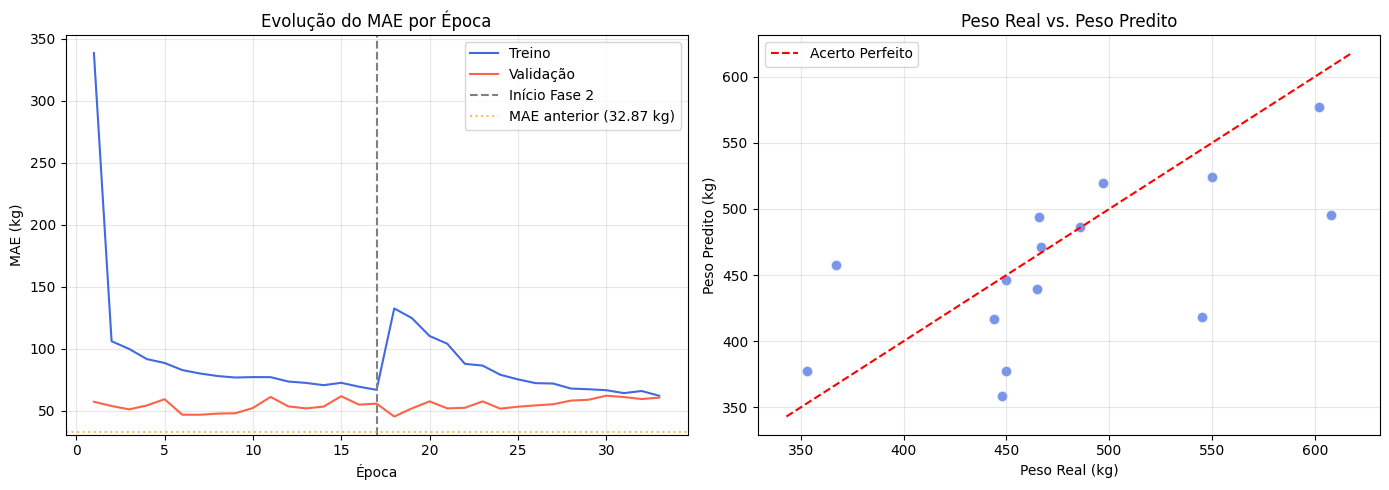


📊 RESULTADOS FINAIS NO TESTE:
   MAE  : 45.18 kg
   RMSE : 60.37 kg
   Erro% médio: 9.5%

--- Detalhes por animal (teste) ---
  ⚠️  Real: 448 kg | IA: 359 kg | Erro: 89 kg
  ⚠️  Real: 608 kg | IA: 496 kg | Erro: 112 kg
  ⚠️  Real: 367 kg | IA: 458 kg | Erro: 91 kg
  ⚠️  Real: 545 kg | IA: 418 kg | Erro: 127 kg
  ✅ Real: 550 kg | IA: 525 kg | Erro: 25 kg
  ⚠️  Real: 450 kg | IA: 378 kg | Erro: 72 kg
  ✅ Real: 466 kg | IA: 494 kg | Erro: 28 kg
  ✅ Real: 602 kg | IA: 577 kg | Erro: 25 kg
  ✅ Real: 444 kg | IA: 417 kg | Erro: 27 kg
  ✅ Real: 497 kg | IA: 519 kg | Erro: 22 kg
  ✅ Real: 486 kg | IA: 486 kg | Erro: 0 kg
  ✅ Real: 465 kg | IA: 440 kg | Erro: 25 kg
  ✅ Real: 467 kg | IA: 471 kg | Erro: 4 kg
  ✅ Real: 353 kg | IA: 378 kg | Erro: 25 kg
  ✅ Real: 450 kg | IA: 446 kg | Erro: 4 kg


In [24]:
# ============================================================
# CÉLULA 9 — GRÁFICO DE EVOLUÇÃO DO TREINO
# ============================================================
import matplotlib.pyplot as plt

# Concatenar histórico das duas fases
loss_total    = hist1.history['loss']    + hist2.history['loss']
val_loss_total= hist1.history['val_loss']+ hist2.history['val_loss']
epocas = range(1, len(loss_total) + 1)
divisor = len(hist1.history['loss'])  # onde começa a fase 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curva de Loss
axes[0].plot(epocas, loss_total,     label='Treino',    color='royalblue')
axes[0].plot(epocas, val_loss_total, label='Validação', color='tomato')
axes[0].axvline(x=divisor, color='gray', linestyle='--', label='Início Fase 2')
axes[0].axhline(y=32.87, color='orange', linestyle=':', alpha=0.7, label='MAE anterior (32.87 kg)')
axes[0].set_title('Evolução do MAE por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MAE (kg)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Scatter peso real vs predito
preds_teste = modelo.predict(X_test, verbose=0).flatten()
axes[1].scatter(y_test, preds_teste, color='royalblue', alpha=0.7, edgecolors='white', s=60)
lim = [min(y_test.min(), preds_teste.min()) - 10, max(y_test.max(), preds_teste.max()) + 10]
axes[1].plot(lim, lim, 'r--', label='Acerto Perfeito')
axes[1].set_title('Peso Real vs. Peso Predito')
axes[1].set_xlabel('Peso Real (kg)')
axes[1].set_ylabel('Peso Predito (kg)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUT}/curva_treino_v3.png', dpi=120)
plt.show()

# Métricas finais
mae_final = np.mean(np.abs(y_test - preds_teste))
print(f'\n📊 RESULTADOS FINAIS NO TESTE:')
print(f'   MAE  : {mae_final:.2f} kg')
print(f'   RMSE : {np.sqrt(np.mean((y_test - preds_teste)**2)):.2f} kg')
print(f'   Erro% médio: {np.mean(np.abs(y_test - preds_teste) / y_test) * 100:.1f}%')

# Detalhes por animal
print('\n--- Detalhes por animal (teste) ---')
for i, (real, pred) in enumerate(zip(y_test, preds_teste)):
    sinal = '✅' if abs(real - pred) < 30 else '⚠️ '
    print(f'  {sinal} Real: {real:.0f} kg | IA: {pred:.0f} kg | Erro: {abs(real-pred):.0f} kg')

In [25]:
# ============================================================
# CÉLULA 10 — EXPORTAR MODELO .h5 E .tflite
# ============================================================
# O .tflite é o arquivo que vai substituir o model.tflite
# na pasta models/ do teu projeto Agora (v2).

import os

# --- Salvar .h5 (Keras completo) ---
h5_path = os.path.join(PATH_OUT, 'modelo_rayvora_v3.h5')
modelo.save(h5_path)
print(f'✅ Modelo .h5 salvo em: {h5_path}')

# --- Converter para TFLite (float32, sem quantização) ---
# float32 = sem perda de precisão numérica (igual ao teu model.tflite atual)
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
converter.optimizations = []  # SEM quantização — preserva precisão float32
tflite_model = converter.convert()

tflite_path = os.path.join(PATH_OUT, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tamanho_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f'✅ Modelo .tflite salvo em: {tflite_path}')
print(f'   Tamanho: {tamanho_mb:.1f} MB')

print('\n' + '='*60)
print('PRÓXIMO PASSO:')
print('Baixar o model.tflite acima e substituir o arquivo em:')
print('  Projeto_Bois_IA/models/model.tflite')
print('='*60)

✅ Modelo .h5 salvo em: /content/drive/MyDrive/Projeto_Bois_IA/modelos_v3/modelo_rayvora_v3.h5
Saved artifact at '/tmp/tmp93lh686l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_316')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140358335792144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335792912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335796752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335792720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335795216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335793680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335795984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335791760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140358335793296: TensorSpec(shape=(), dtype=tf.resource,

In [26]:
# ============================================================
# CÉLULA 11 — VERIFICAR O TFLITE (Teste de sanidade)
# ============================================================
# Antes de substituir no app, verifica se o tflite produz
# os mesmos resultados que o modelo Keras.

import numpy as np

# Carrega o intérprete TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_det = interpreter.get_input_details()
out_det = interpreter.get_output_details()

print('🔍 Teste de sanidade: Keras vs TFLite')
print(f'   Input shape esperado: {inp_det[0]["shape"]}')
print()

erros = []
for i in range(min(5, len(X_test))):
    img = np.expand_dims(X_test[i], axis=0)

    # Keras
    pred_keras  = modelo.predict(img, verbose=0)[0][0]

    # TFLite
    interpreter.set_tensor(inp_det[0]['index'], img)
    interpreter.invoke()
    pred_tflite = interpreter.get_tensor(out_det[0]['index'])[0][0]

    diff = abs(pred_keras - pred_tflite)
    erros.append(diff)
    print(f'  Boi {i+1}: Keras={pred_keras:.2f}kg | TFLite={pred_tflite:.2f}kg | Diferença={diff:.4f}kg')

print(f'\n✅ Diferença média Keras→TFLite: {np.mean(erros):.4f} kg (deve ser < 0.01 kg)')
if np.mean(erros) < 0.1:
    print('🎉 Conversão perfeita! O model.tflite está pronto para o app.')
else:
    print('⚠️  Diferença alta. Verifica se a conversão foi feita sem quantização.')

🔍 Teste de sanidade: Keras vs TFLite
   Input shape esperado: [  1 128 128   3]



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Boi 1: Keras=358.61kg | TFLite=358.61kg | Diferença=0.0004kg
  Boi 2: Keras=495.80kg | TFLite=495.80kg | Diferença=0.0003kg
  Boi 3: Keras=457.79kg | TFLite=457.79kg | Diferença=0.0002kg
  Boi 4: Keras=418.27kg | TFLite=418.27kg | Diferença=0.0001kg
  Boi 5: Keras=524.55kg | TFLite=524.55kg | Diferença=0.0004kg

✅ Diferença média Keras→TFLite: 0.0003 kg (deve ser < 0.01 kg)
🎉 Conversão perfeita! O model.tflite está pronto para o app.


In [27]:
# ============================================================
# CÉLULA 12 — DOWNLOAD DO MODEL.TFLITE
# ============================================================
from google.colab import files

print('📥 A fazer download do model.tflite...')
files.download(tflite_path)

print('\n📋 INSTRUÇÕES FINAIS:')
print('1. Mover o model.tflite baixado para:')
print('   Projeto_Bois_IA/models/model.tflite  (substituir o antigo)')
print()
print('2. O app.py já usa ai_edge_litert e está pronto.')
print('   Apenas reinicia o Streamlit e o novo modelo entra em ação.')
print()
print('3. (Opcional) Também podes baixar o .h5 para backup:')
# files.download(h5_path)  # ← descomenta se quiser
print(f'   {h5_path}')

📥 A fazer download do model.tflite...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📋 INSTRUÇÕES FINAIS:
1. Mover o model.tflite baixado para:
   Projeto_Bois_IA/models/model.tflite  (substituir o antigo)

2. O app.py já usa ai_edge_litert e está pronto.
   Apenas reinicia o Streamlit e o novo modelo entra em ação.

3. (Opcional) Também podes baixar o .h5 para backup:
   /content/drive/MyDrive/Projeto_Bois_IA/modelos_v3/modelo_rayvora_v3.h5
